# Server Evaluation

This File reads all csv files of the ./server folder and concatenates them to a single dataframe, then used for further evaluation.

In [14]:
import pandas as pd
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
folder_path = './server'  

csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

df = pd.concat((pd.read_csv(file, delimiter=", ", engine="python") for file in csv_files), ignore_index=True)
df["Distance (m)"] = df["Distance (m)"].replace(30,5)

In [26]:
df[df["Package Loss (%)"] < 0]

,Transport Protocol,Scenario,Distance (m),Transfer Speed (Mbps),Package Loss (%),Package Size (Bytes),Number of Packages
609,QUIC,Forest,5,0.360382,-10.0,128,1000


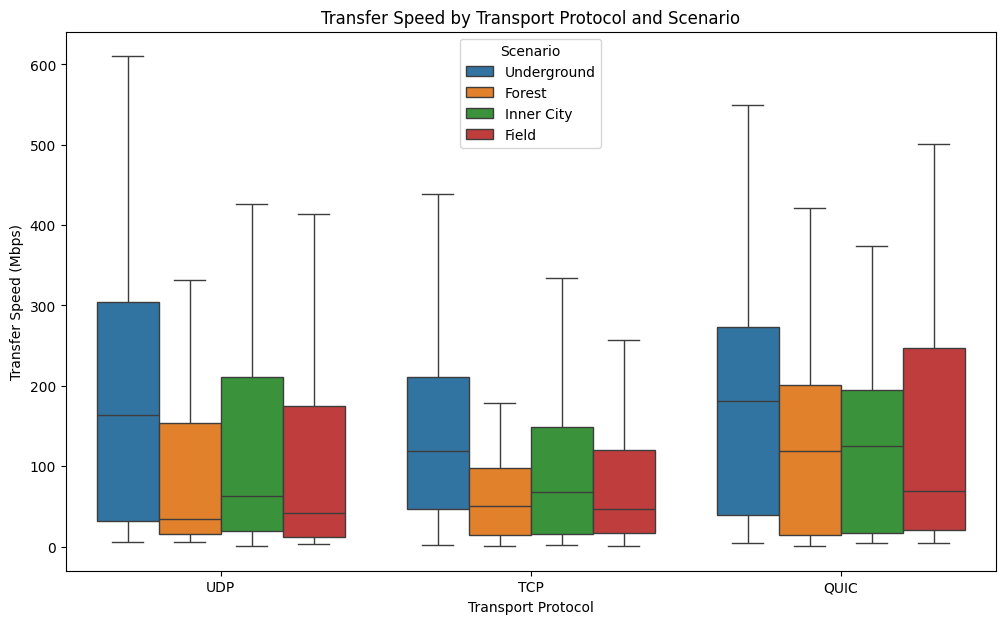

In [17]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Transport Protocol', y='Transfer Speed (Mbps)', hue='Scenario', data=df, showfliers=False)
plt.title('Transfer Speed by Transport Protocol and Scenario')
plt.ylabel('Transfer Speed (Mbps)')
plt.xlabel('Transport Protocol')
plt.legend(title='Scenario')
plt.show()

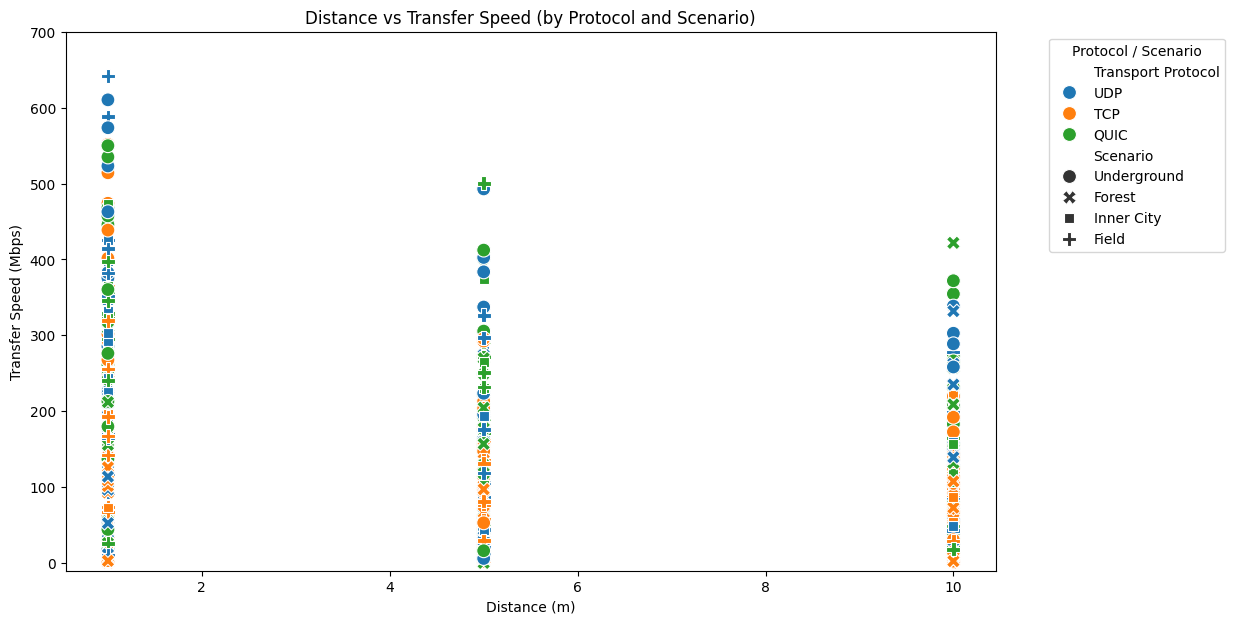

In [22]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Distance (m)', y='Transfer Speed (Mbps)', hue='Transport Protocol', style='Scenario', data=df, s=100)
plt.title('Distance vs Transfer Speed (by Protocol and Scenario)')
plt.ylim(-10,700)
plt.xlabel('Distance (m)')
plt.ylabel('Transfer Speed (Mbps)')
plt.legend(title='Protocol / Scenario', bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

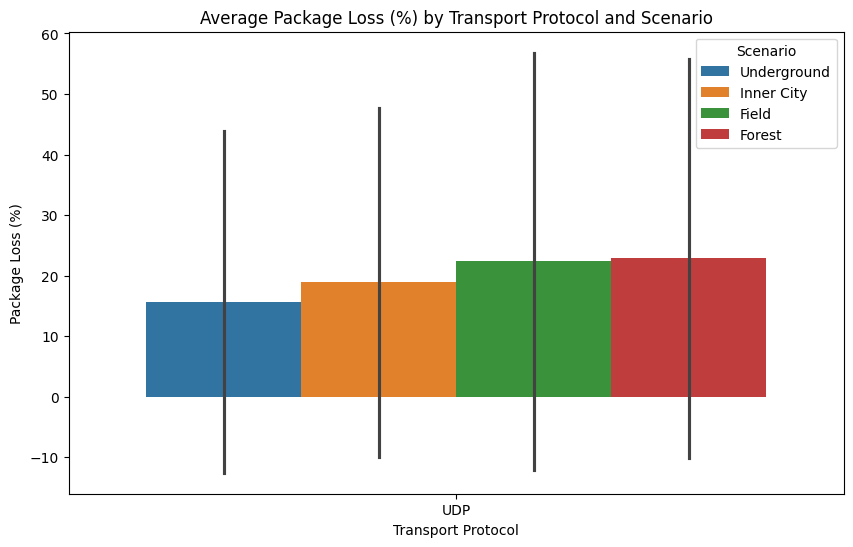

In [23]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Transport Protocol', y='Package Loss (%)', hue='Scenario', data=df[df["Transport Protocol"] == "UDP"], estimator='mean', errorbar='sd')
plt.title('Average Package Loss (%) by Transport Protocol and Scenario')
plt.ylabel('Package Loss (%)')
plt.xlabel('Transport Protocol')
plt.legend(title='Scenario')
plt.show()

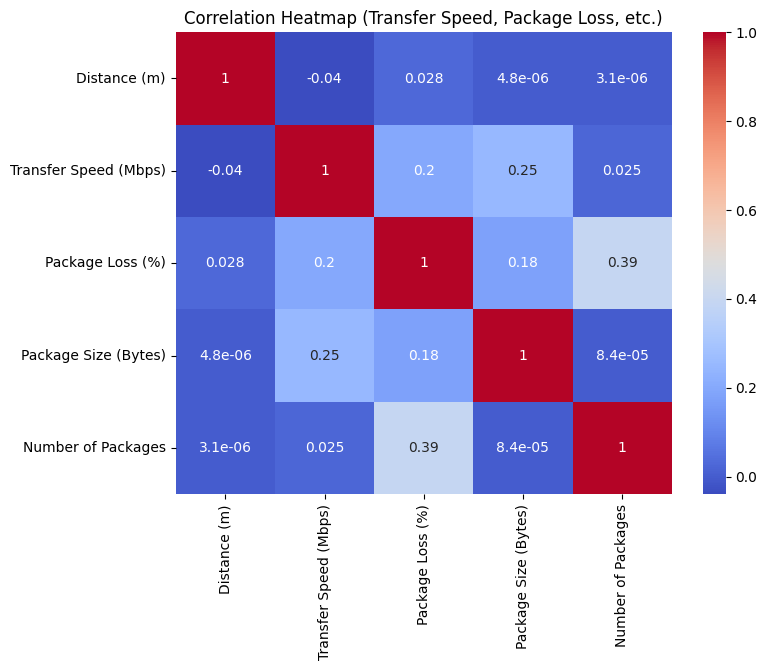

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Transfer Speed, Package Loss, etc.)')
plt.show()